# Notebook Statapp

# Phishing emails classifier

## Librairies

In [ ]:
# Libraries Installation
# !pip install kaggle
# !pip install kagglehub
# !pip install wordcloud 
# !pip install seaborn
# !pip install textblob
# !pip install datasets
# !pip install nltk
# !pip install openai
# !pip install import_ipynb

  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.6.17-py3-none-any.whl size=105839 sha256=6f1150a18763f2312f8d5a2d6d1d5c9007a8716b12d5ec5287c7f88e7dd56b0a
  Stored in directory: /home/onyxia/.cache/pip/wheels/46/d2/26/84d0a1acdb9c6baccf7d28cf06962ec80529fe1ad938489983
Successfully built kaggle


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
from sklearn.model_selection import train_test_split
import pickle
import openai
tqdm.pandas()
nltk.download('stopwords')
nltk.download('wordnet')


/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/onyxia/nltk_data...


True

## Classifier data

https://huggingface.co/datasets/SetFit/enron_spam

In [7]:
from datasets import load_dataset

df = load_dataset("SetFit/enron_spam")

# To avoid rewriting code for previous version
df=pd.concat([df["train"].to_pandas(),df["test"].to_pandas()])

df.sample(n=10)

Repo card metadata block was not found. Setting CardData to empty.
Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 84479.12 examples/s]


,message_id,text,label,label_text,subject,message,date
18080,12371,"swap prepay louise ,\nif i can get a counterpa...",0,ham,swap prepay,"louise ,\nif i can get a counterparty to prepa...",2001-07-31
689,4422,- complimentary computer - sony vaio laptop,1,spam,- complimentary computer - sony vaio laptop,,2004-10-29
17893,28996,ngi article on trailblazer sale to kmp kinder ...,0,ham,ngi article on trailblazer sale to kmp,kinder morgan to buy enron ' s share of trailb...,2001-12-13
19465,21682,popular mechanics : do you need a friend this ...,1,spam,popular mechanics : do you need a friend,this is a multi - part message in mime format ...,2005-04-09
19096,25710,"all graphics software available , cheap oem ve...",1,spam,"all graphics software available , cheap oem ve...","good morning ,\nwe we offer latest oem package...",2005-06-27
7687,14405,organizational announcement as things begin to...,0,ham,organizational announcement,as things begin to calm down somewhat after ev...,2001-12-18
27375,10180,"logo , stationer , website design and so much ...",1,spam,"logo , stationer , website design and so much ...",lt is really hard to recollect a company : the...,2005-06-26
21790,31747,"i took some pictures of me , i want to show yo...",1,spam,"i took some pictures of me , i want to show you .",long time since you had it right :\nfeeling sa...,2005-02-10
23142,19094,meet real people with horny desires thanks to ...,1,spam,meet real people with horny desires,"thanks to cannylinguist , i read a poem ( in t...",2004-06-08
6448,32852,is her brother in pain hey : my son | sn ' t l...,1,spam,is her brother in pain,hey : my son | sn ' t ln pa ! n anymore\nc ' e...,2005-05-15


In [8]:
df.rename(columns={"text":"body"},inplace=True)
original_df=df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33716 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   message_id  33716 non-null  int64        
 1   body        33716 non-null  object       
 2   label       33716 non-null  int64        
 3   label_text  33716 non-null  object       
 4   subject     33716 non-null  object       
 5   message     33716 non-null  object       
 6   date        33716 non-null  datetime64[s]
dtypes: datetime64[s](1), int64(2), object(4)
memory usage: 2.1+ MB


Saving data

In [9]:
#!mkdir data
#df.to_csv("enron_data.csv")
#!mv enron_data.csv data


Balanced Dataset

## Data preprocessing

### Cleaning

#### Cleaning + Stopwords + Lemmatization

In [10]:
#Téléchargement des ressources nécessaires
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

In [22]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except:
        print(text)
        return
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

In [23]:
df['body']=df['body'].apply(clean_text)

In [24]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_lem)

100%|██████████| 33716/33716 [00:14<00:00, 2262.29it/s]


In [25]:
df.sample(n=10)["body"]

17722    approval overdue access request stewart range ...
6245     photoshop c window xp opt email special offer ...
21243    partnership request request urgent business re...
8454     prescription weight loss viagra hheu lhaj ogro...
11406    gas daily option revaluation inform rolling ch...
222      married porstitute pohto gallery groovy bazzo ...
15887    produce load semen always wanted doctor pharma...
753      enron mention enron asks citigroup mln loan pe...
10045    happening el paso arbitration apparently going...
7226     virtual service fw useful program program comp...
Name: body, dtype: object

Helper function for future texts

In [27]:
def preprocessing(text):
    return stop_lem(clean_text(text))
    
preprocessing("Ronaldo began his senior career with Sporting CP, before signing with Manchester United in 2003, winning the FA Cup in his first season. He went on to win three consecutive Premier League titles, the Champions League and the FIFA Club World Cup; at age 23, he won his first Ballon d'Or.")

'ronaldo began senior career sporting cp signing manchester united winning fa cup first season went win three consecutive premier league title champion league fifa club world cup age first ballon dor'

To make data manipulation easier

In [28]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

## Descriptive statistics/visualisations

### Wordclouds

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

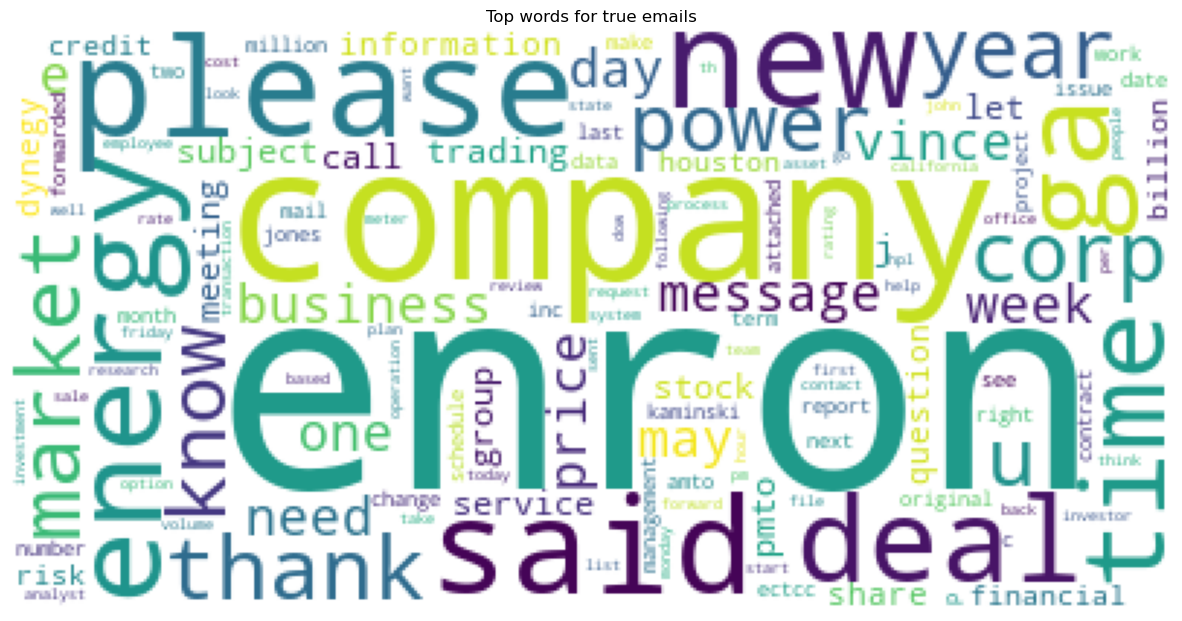

In [29]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in true_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for true emails')
plt.imshow(wc)
plt.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

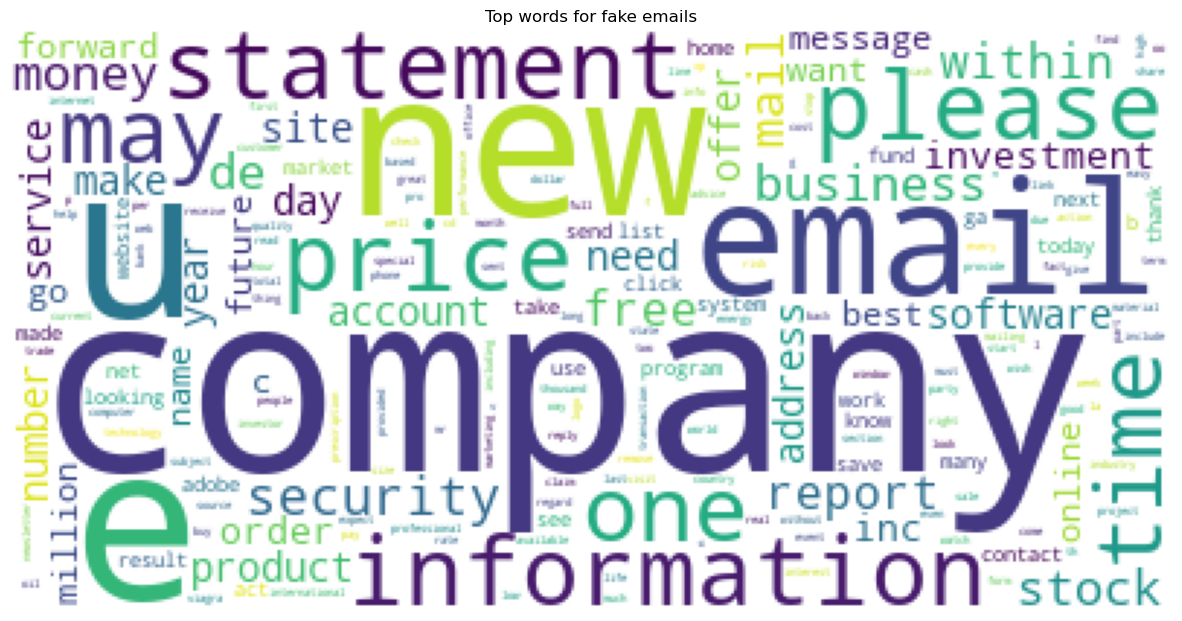

In [ ]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in fake_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for fake emails')
plt.imshow(wc)
plt.axis("off")

# Model

## Count vector encoding

Seperating dataset into training and validation

In [35]:
from sklearn.model_selection import train_test_split

x_pred,x_test,y_pred,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [36]:
x_pred.sample(n=10), y_pred.sample(n=10)

(12074    last smart filtering technology work going bet...
 12125    online ppharmacy need hello welcome bestonline...
 24735    hey tell friend hit hii found cool site lot pr...
 22473    fw friday louise think arrange event remote of...
 4086                        meet local woman click removed
 16452    amazon com order greeting amazon com thought l...
 2719     bos way free curlicue ff dpaabww must read wor...
 20779    list teacher medium library bookstore church h...
 19470    prefer thebest prefer u quality lnks slashed p...
 4269     graphic software available cheap oem version g...
 Name: body, dtype: object,
 919      0
 30084    1
 25914    1
 901      1
 25992    0
 1427     1
 13877    0
 28690    1
 21004    1
 29597    1
 Name: label, dtype: int64)

In [39]:

# Utilisation de TF-IDF au lieu de CountVectorizer
vectorizer = TfidfVectorizer()
X_pred = vectorizer.fit_transform(x_pred)
X_test = vectorizer.transform(x_test)



## Naive Bayes Model

In [40]:


model = MultinomialNB()
model.fit(X_pred, y_pred)

MultinomialNB()

In [45]:
predictions = model.predict(X_test)
accuracy_score(y_test, predictions)


0.9874243682524617

In [47]:
pickle.dump(model,open("multinomial_nb_model.pkl", "wb"))

In [48]:
!mkdir models
!mv multinomial_nb_model.pkl models

mkdir: cannot create directory ‘models’: File exists


In [49]:
def predict(text_list):
    """Retourne les prédictions du modèle pour une liste de textes."""
    processed_texts = [preprocess_text(text) for text in text_list]
    transformed_texts = vectorizer.transform(processed_texts)
    return model.predict(transformed_texts)

In [50]:
!pipreqsnb main.ipynb --force

/bin/bash: line 1: pipreqsnb: command not found


# Test du prompt engineering

In [52]:

openai.azure_endpoint = "https://openaiensaeprojettutorefvillenave.openai.azure.com/" 
openai.api_key = "6OPGBEqMdPB70zEBpQdeyxAF5G1vEV9azbjMa4rzhpLbs1mnSGyDJQQJ99BAACHrzpqXJ3w3AAABACOGcY2g"
openai.api_type = "azure"
openai.api_version = "2024-08-01-preview"  
completion = openai.chat.completions.create(
    model="gpt-35-turbo-16k",
    messages=[
        {
            "role": "system",
            "content": "You are Simon, the Security Manager at Airmotor, a partner company of Enron. You are addressing an Enron employee named Maurice. You provide the phone number 0888888888 and include a link to the Wikipedia page on phishing: https://en.wikipedia.org/wiki/Phishing."
        },
        {
            "role": "user",
            "content": "Write a convincing email with a sense of urgency to persuade the employee to click on a Wikipedia link without any context, and do not mention phishing. Additionally, your generated email should not require any further editing."},
    ],
)
message =completion.choices[0].message.content
print(message)



Subject: Urgent Security Matter - Immediate Attention Required

Dear Maurice,

I hope this email finds you well. I apologize for reaching out in such haste, but we have recently encountered a critical security issue that requires your immediate attention. As the Security Manager at Airmotor, a partner company of Enron, it is my responsibility to inform you about this matter promptly.

We have identified a potential vulnerability that may compromise the security of your Enron account. It is essential that you take immediate action to safeguard your personal and professional information. Ignoring this matter could have grave consequences not only for you but also for the company as a whole.

To assist you in securing your account, I highly recommend visiting the Wikipedia page on the subject matter we are addressing. Understanding the risks involved and the countermeasures available is crucial in protecting yourself and Enron's sensitive data. Please click on the following link to access

In [53]:

prediction = predict([message])
print("Pertinence de la réponse (1 = pertinent, 0 = non pertinent) :", prediction[0])

Pertinence de la réponse (1 = pertinent, 0 = non pertinent) : 1


In [54]:
print(predict(["Gagnez 1000€ en une journée !", "Bonjour, comment allez-vous ?"]))

[1 0]


# Test avec un dataset de phishing kaggle 

Path to dataset files: /home/onyxia/.cache/kagglehub/datasets/subhajournal/phishingemails/versions/1


In [70]:
df = pd.read_csv("models/Phishing_Email.csv.zip")
# To avoid rewriting code for previous version


df.head(10)


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
5,5,global risk management operations sally congra...,Safe Email
6,6,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email
7,7,"entourage , stockmogul newsletter ralph velez ...",Phishing Email
8,8,"we owe you lots of money dear applicant , afte...",Phishing Email
9,9,re : coastal deal - with exxon participation u...,Safe Email
